# Hasselt v2 — MLPartB3 Dataset

All improvements integrated:
- Reduced feature set (7 inputs → 6 force + 3 fatigue outputs)
- Redundant feature removal (L≡Dx, A≡w×h, FRtop constant)
- Dimensionless feature engineering
- Stratified data splitting by FOS bins
- LayerNorm + skip connections + dropout
- HuberLoss (forces) + asymmetric FatigueLoss (fatigue)
- AdamW with weight decay, no scheduler
- Experiment logger (CSV)
- SHAP analysis


## Cell 1 — Imports

In [1]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import os
import csv
from datetime import datetime
from sklearn.model_selection import train_test_split
import shap


## Cell 2 — General Parameters

In [2]:
alpha      = 0.5
dropout    = 0.15
Lambda     = 0.0
epochs     = 800
seed       = 42
patience   = 80
batch_size = 16


## Cell 3 — Load & Clean Data

In [3]:
notebook_dir = os.getcwd()
file_path = os.path.join(notebook_dir, 'Data', 'MLPartB3.xlsx')

df_training = pd.read_excel(file_path)
print(f"Raw shape: {df_training.shape}")

# ── Drop redundant / constant columns ────────────────────────────
# FRtop is constant (-4.5 everywhere) → useless
# Dx is perfectly correlated with L (L/Dx = 0.5545 constant) → redundant
# A (m2) = width × height exactly → redundant
drop_cols = ['FRtop (N)', 'Dx', 'A (m2)']
df_training = df_training.drop(columns=drop_cols, errors='ignore')

print(f"After dropping {drop_cols}:")
print(f"  Shape: {df_training.shape}")
print(f"  Columns: {df_training.columns.tolist()}")

# Verify no NaN
assert df_training.isna().sum().sum() == 0, "NaN values found"
print(f"  NaN: 0")

# Quick stats
print(f"\n  {'Column':>15} | {'Min':>12} | {'Max':>12} | {'Mean':>12}")
print(f"  {'-'*58}")
for col in df_training.columns:
    vals = df_training[col]
    print(f"  {col:>15} | {vals.min():>12.4f} | {vals.max():>12.4f} | {vals.mean():>12.4f}")


Raw shape: (946, 18)
After dropping ['FRtop (N)', 'Dx', 'A (m2)']:
  Shape: (946, 15)
  Columns: ['L (m)', 'width (m)', 'height (m)', 'pin_dia (m)', 'density', '|RT0|max', '|P1|max', '|B0|max', '|RT0|min', '|P1|min', '|B0|min', 'FOS', 'N_To', 'N_B0', 'N_P1']
  NaN: 0

           Column |          Min |          Max |         Mean
  ----------------------------------------------------------
            L (m) |       0.0711 |       1.1774 |       0.4964
        width (m) |       0.0050 |       0.0117 |       0.0083
       height (m) |       0.0150 |       0.0350 |       0.0250
      pin_dia (m) |       0.0040 |       0.0080 |       0.0060
          density |    2600.0050 |    2699.7721 |    2650.0709
         |RT0|max |      10.0066 |     948.3418 |     160.8196
          |P1|max |      17.7269 |    1190.7912 |     207.0222
          |B0|max |      15.9513 |     957.3172 |     169.5549
         |RT0|min |       4.0648 |     359.6590 |      56.2483
          |P1|min |       9.5881 |     4

## Cell 4 — Dimensionless Feature Engineering

With only 5 independent geometry inputs (L, width, height, pin_dia, density) + FOS,
we create physics-based ratios:


In [4]:
# Geometry ratios
df_training['h/w']       = df_training['height (m)'] / df_training['width (m)']
df_training['pin/w']     = df_training['pin_dia (m)'] / df_training['width (m)']
df_training['pin/h']     = df_training['pin_dia (m)'] / df_training['height (m)']
df_training['L/h']       = df_training['L (m)'] / df_training['height (m)']
df_training['L/w']       = df_training['L (m)'] / df_training['width (m)']

# Cross-section aspect
df_training['A_ratio']   = (df_training['width (m)'] * df_training['height (m)']) / (df_training['L (m)'] ** 2)

# Pin slenderness
df_training['pin_slenderness'] = df_training['L (m)'] / df_training['pin_dia (m)']

dimensionless_cols = [
    'h/w', 'pin/w', 'pin/h', 'L/h', 'L/w',
    'A_ratio', 'pin_slenderness',
]

# Verify no NaN/Inf
for col in dimensionless_cols:
    n_bad = (~np.isfinite(df_training[col])).sum()
    if n_bad > 0:
        print(f"  ⚠ {col}: {n_bad} non-finite values — clipping")
        df_training[col] = df_training[col].replace([np.inf, -np.inf], np.nan)
        df_training[col] = df_training[col].fillna(df_training[col].median())

print(f"  Added {len(dimensionless_cols)} dimensionless features")
print(f"  New shape: {df_training.shape}")
print(f"  New columns: {df_training.columns.tolist()}")


  Added 7 dimensionless features
  New shape: (946, 22)
  New columns: ['L (m)', 'width (m)', 'height (m)', 'pin_dia (m)', 'density', '|RT0|max', '|P1|max', '|B0|max', '|RT0|min', '|P1|min', '|B0|min', 'FOS', 'N_To', 'N_B0', 'N_P1', 'h/w', 'pin/w', 'pin/h', 'L/h', 'L/w', 'A_ratio', 'pin_slenderness']


## Cell 5 — Target & Feature Definitions

In [5]:
force_cols   = ['|RT0|max', '|P1|max', '|B0|max',
                '|RT0|min', '|P1|min', '|B0|min']
fatigue_cols = ['N_To', 'N_B0', 'N_P1']

target_col = force_cols + fatigue_cols
n_force    = len(force_cols)     # 6
n_fatigue  = len(fatigue_cols)   # 3
n_output   = len(target_col)     # 9

Yf = df_training[force_cols].copy()
Ya = df_training[fatigue_cols].copy()
Y  = df_training[target_col].copy()
X  = df_training.drop(columns=target_col, errors='ignore').copy()

feature_cols = list(X.columns)

assert np.isfinite(Ya.values).all(), "Non-finite fatigue values"

x  = torch.tensor(X.values,  dtype=torch.float32)
yf = torch.tensor(Yf.values, dtype=torch.float32)
ya = torch.tensor(Ya.values, dtype=torch.float32)
y  = torch.tensor(Y.values,  dtype=torch.float32)

print(f"  Features ({len(feature_cols)}): {feature_cols}")
print(f"  Force targets ({n_force}): {force_cols}")
print(f"  Fatigue targets ({n_fatigue}): {fatigue_cols}")
print(f"\n  x  tensor : {x.shape}   NaN: {torch.isnan(x).sum().item()}")
print(f"  yf tensor : {yf.shape}  NaN: {torch.isnan(yf).sum().item()}")
print(f"  ya tensor : {ya.shape}  NaN: {torch.isnan(ya).sum().item()}")
print(f"\n  ya range  : min={ya.min().item():.3f}  max={ya.max().item():.3f}")


  Features (13): ['L (m)', 'width (m)', 'height (m)', 'pin_dia (m)', 'density', 'FOS', 'h/w', 'pin/w', 'pin/h', 'L/h', 'L/w', 'A_ratio', 'pin_slenderness']
  Force targets (6): ['|RT0|max', '|P1|max', '|B0|max', '|RT0|min', '|P1|min', '|B0|min']
  Fatigue targets (3): ['N_To', 'N_B0', 'N_P1']

  x  tensor : torch.Size([946, 13])   NaN: 0
  yf tensor : torch.Size([946, 6])  NaN: 0
  ya tensor : torch.Size([946, 3])  NaN: 0

  ya range  : min=-16.123  max=47.256


## Cell 6 — Datasets, DataLoaders, Loss Functions

In [6]:
num_workers = 0

class Training(Dataset):
    def __init__(self, x_mix, yf_mix, ya_mix):
        assert x_mix.shape[0] == yf_mix.shape[0] == ya_mix.shape[0]
        self.x_mix  = x_mix
        self.yf_mix = yf_mix
        self.ya_mix = ya_mix
    def __len__(self): return self.x_mix.shape[0]
    def __getitem__(self, idx):
        return (self.x_mix[idx], self.yf_mix[idx], self.ya_mix[idx])


class Validation(Dataset):
    def __init__(self, x, yf, ya):
        assert x.shape[0] == yf.shape[0] == ya.shape[0]
        self.x  = x
        self.yf = yf
        self.ya = ya
    def __len__(self): return self.x.shape[0]
    def __getitem__(self, idx): return self.x[idx], self.yf[idx], self.ya[idx]


def get_dataloaders(train_ds, val_ds, batch_size, num_workers, seed):
    g = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        drop_last=True, num_workers=num_workers, generator=g)
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        drop_last=False, num_workers=num_workers)
    return train_loader, val_loader


class FatigueLoss(nn.Module):
    """Asymmetric Huber: penalises overprediction (unsafe) more."""
    def __init__(self, delta=0.5, overpredict_weight=1.5):
        super().__init__()
        self.delta = delta
        self.w_over = overpredict_weight

    def forward(self, pred, target):
        error = pred - target
        abs_error = error.abs()
        quadratic = 0.5 * error ** 2
        linear    = self.delta * (abs_error - 0.5 * self.delta)
        huber     = torch.where(abs_error <= self.delta, quadratic, linear)
        weight    = torch.where(error > 0, self.w_over, 1.0)
        return (weight * huber).mean()


## Cell 7 — Stratified Data Splitting

FOS has 9 discrete levels — we stratify on FOS so each split
gets proportional representation of every safety factor.
Since all 946 rows are unique (continuous parametric sweep),
group splitting has no exact duplicates to cluster on.


In [7]:
def split_data_stratified(x, yf, ya, seed, train_frac=0.70, val_frac=0.15):
    n = len(x)
    test_frac = 1.0 - train_frac - val_frac

    # Stratify on FOS (column in the original df, mapped to X)
    fos_col_idx = feature_cols.index('FOS') if 'FOS' in feature_cols else None
    if fos_col_idx is not None:
        x_np = x.numpy()
        strata = x_np[:, fos_col_idx]
    else:
        # Fallback: bin primary target
        strata = yf[:, 0].numpy()
        strata = np.digitize(strata, np.percentile(strata, np.linspace(0, 100, 6)[1:-1]))

    indices = np.arange(n)

    # Split 1: train vs (val+test)
    val_test_frac = val_frac + test_frac
    try:
        train_idx, valtest_idx = train_test_split(
            indices, test_size=val_test_frac,
            stratify=strata, random_state=seed)
    except ValueError:
        train_idx, valtest_idx = train_test_split(
            indices, test_size=val_test_frac, random_state=seed)

    # Split 2: val vs test
    relative_test = test_frac / val_test_frac
    valtest_strata = strata[valtest_idx]
    try:
        val_idx, test_idx = train_test_split(
            valtest_idx, test_size=relative_test,
            stratify=valtest_strata, random_state=seed)
    except ValueError:
        val_idx, test_idx = train_test_split(
            valtest_idx, test_size=relative_test, random_state=seed)

    return (torch.tensor(train_idx), torch.tensor(val_idx),
            torch.tensor(test_idx))


def mixup(x, yf, ya, alpha=alpha, seed=None):
    if seed is not None:
        np.random.seed(seed)
    N     = x.size(0)
    lam   = np.random.beta(alpha, alpha, size=N)
    lam   = np.maximum(lam, 1 - lam)
    lam_t = torch.tensor(lam, dtype=torch.float32).unsqueeze(1)
    idx_p = torch.randperm(N)
    x_mix  = lam_t * x  + (1 - lam_t) * x[idx_p]
    yf_mix = lam_t * yf + (1 - lam_t) * yf[idx_p]
    ya_mix = lam_t * ya + (1 - lam_t) * ya[idx_p]
    return x_mix, yf_mix, ya_mix


# Run the split
train_idx, val_idx, test_idx = split_data_stratified(x, yf, ya, seed=seed)

print(f'  Train : {len(train_idx):>3} samples  ({len(train_idx)/len(x)*100:.0f}%)')
print(f'  Val   : {len(val_idx):>3} samples  ({len(val_idx)/len(x)*100:.0f}%)')
print(f'  Test  : {len(test_idx):>3} samples  ({len(test_idx)/len(x)*100:.0f}%)')
for col_i, col in enumerate(target_col):
    tr_min, tr_max = y[train_idx, col_i].min(), y[train_idx, col_i].max()
    va_min, va_max = y[val_idx, col_i].min(), y[val_idx, col_i].max()
    te_min, te_max = y[test_idx, col_i].min(), y[test_idx, col_i].max()
    flag = '  ⚠ extrap' if (va_max > tr_max or te_max > tr_max) else ''
    print(f'  {col} — Train [{tr_min:.2f}, {tr_max:.2f}]  '
          f'Val [{va_min:.2f}, {va_max:.2f}]  '
          f'Test [{te_min:.2f}, {te_max:.2f}]{flag}')

# FOS distribution check
if 'FOS' in feature_cols:
    fos_idx = feature_cols.index('FOS')
    for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
        fos_vals = x[idx, fos_idx].numpy()
        unique, counts = np.unique(fos_vals, return_counts=True)
        dist = ', '.join([f'{v:.1f}:{c}' for v, c in zip(unique, counts)])
        print(f'  FOS {name}: {dist}')


  Train : 662 samples  (70%)
  Val   : 141 samples  (15%)
  Test  : 143 samples  (15%)
  |RT0|max — Train [10.01, 948.34]  Val [10.57, 769.72]  Test [10.58, 702.46]
  |P1|max — Train [17.73, 1190.79]  Val [18.28, 967.54]  Test [19.22, 883.43]
  |B0|max — Train [15.95, 957.32]  Val [16.24, 778.72]  Test [18.60, 711.48]
  |RT0|min — Train [4.06, 359.66]  Val [4.98, 292.44]  Test [4.61, 242.69]
  |P1|min — Train [9.59, 454.82]  Val [11.86, 370.89]  Test [11.19, 308.47]
  |B0|min — Train [10.28, 369.40]  Val [12.59, 302.46]  Test [12.17, 252.22]
  N_To — Train [0.94, 44.81]  Val [6.32, 41.29]  Test [3.30, 46.15]  ⚠ extrap
  N_B0 — Train [0.55, 47.26]  Val [6.10, 42.75]  Test [3.04, 45.27]
  N_P1 — Train [-16.12, 44.02]  Val [1.14, 40.54]  Test [-1.35, 45.21]  ⚠ extrap
  FOS Train: 1.0:81, 1.2:76, 1.5:64, 1.8:74, 2.0:84, 2.2:72, 2.5:68, 2.8:74, 3.0:69
  FOS Val: 1.0:17, 1.2:16, 1.5:14, 1.8:16, 2.0:18, 2.2:15, 2.5:14, 2.8:16, 3.0:15
  FOS Test: 1.0:17, 1.2:17, 1.5:13, 1.8:16, 2.0:18, 2.2:16,

## Cell 8 — Model Architecture

With only 12 input features (5 raw + 7 dimensionless + FOS + density),
the network can be moderate: 128→256 for forces, 64→128 for fatigue.


In [8]:
class Sohoite_Force(nn.Module):
    def __init__(self, input_dim, n_force=n_force, dropout=dropout):
        super().__init__()
        self.hidden1 = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(128, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.skip  = nn.Linear(input_dim, 256)
        self.heads = nn.ModuleList([nn.Linear(256, 1) for _ in range(n_force)])
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        h1 = self.hidden1(x)
        h2 = self.hidden2(h1)
        h2 = h2 + self.skip(x)
        return torch.cat([head(h2) for head in self.heads], dim=1)


class Sohoite_Fatigue(nn.Module):
    def __init__(self, input_dim, n_force=n_force, n_fatigue=n_fatigue, dropout=dropout):
        super().__init__()
        combined_dim = input_dim + n_force
        self.hidden1 = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(64, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.skip  = nn.Linear(combined_dim, 128)
        self.heads = nn.ModuleList([nn.Linear(128, 1) for _ in range(n_fatigue)])
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, Force_P):
        combined = torch.cat([x, Force_P], dim=1)
        h1 = self.hidden1(combined)
        h2 = self.hidden2(h1)
        h2 = h2 + self.skip(combined)
        return torch.cat([head(h2) for head in self.heads], dim=1)


## Cell 9 — Training & Evaluation Functions

In [9]:
def train_force_epoch(force_model, loader, optimizer, device):
    force_model.train()
    criterion  = nn.HuberLoss(delta=1.0)
    total_loss = 0.0
    for x_mix, yf_mix, _ in loader:
        x_mix  = x_mix.to(device)
        yf_mix = yf_mix.to(device)
        optimizer.zero_grad()
        pred_forces = force_model(x_mix)
        loss = criterion(pred_forces, yf_mix)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(force_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(x_mix)
    return total_loss / len(loader.dataset)


def train_fatigue_epoch(force_model, fatigue_model, loader, optimizer, device):
    force_model.eval()
    fatigue_model.train()
    criterion  = FatigueLoss(delta=0.5, overpredict_weight=1.5)
    total_loss = 0.0
    for x_mix, _, ya_mix in loader:
        x_mix  = x_mix.to(device)
        ya_mix = ya_mix.to(device)
        optimizer.zero_grad()
        with torch.no_grad():
            pred_forces = force_model(x_mix)
        pred_fatigue = fatigue_model(x_mix, pred_forces)
        loss = criterion(pred_fatigue, ya_mix)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(fatigue_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(x_mix)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_force(force_model, loader, device):
    force_model.eval()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    all_pf, all_tf = [], []
    for x_batch, yf_batch, ya_batch in loader:
        x_batch  = x_batch.to(device)
        yf_batch = yf_batch.to(device)
        pred_f = force_model(x_batch)
        total_loss += criterion(pred_f, yf_batch).item() * len(x_batch)
        all_pf.append(pred_f.cpu())
        all_tf.append(yf_batch.cpu())
    return (total_loss / len(loader.dataset),
            torch.cat(all_pf), torch.cat(all_tf))


@torch.no_grad()
def evaluate_fatigue(force_model, fatigue_model, loader, device):
    force_model.eval()
    fatigue_model.eval()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    all_pa, all_ta = [], []
    for x_batch, yf_batch, ya_batch in loader:
        x_batch  = x_batch.to(device)
        ya_batch = ya_batch.to(device)
        pred_f  = force_model(x_batch)
        pred_fa = fatigue_model(x_batch, pred_f)
        total_loss += criterion(pred_fa, ya_batch).item() * len(x_batch)
        all_pa.append(pred_fa.cpu())
        all_ta.append(ya_batch.cpu())
    return (total_loss / len(loader.dataset),
            torch.cat(all_pa), torch.cat(all_ta))


def tester(y_pred_norm, y_true_norm, y_mean, y_std, cols):
    y_pred = (y_pred_norm * y_std + y_mean).numpy()
    y_true = (y_true_norm * y_std + y_mean).numpy()
    results = {}
    for i, col in enumerate(cols):
        err    = y_pred[:, i] - y_true[:, i]
        mae    = float(np.mean(np.abs(err)))
        rmse   = float(np.sqrt(np.mean(err ** 2)))
        ss_res = np.sum(err ** 2)
        ss_tot = np.sum((y_true[:, i] - y_true[:, i].mean()) ** 2)
        r2     = float(1 - ss_res / (ss_tot + 1e-8))
        results[col] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    mean_mae = float(np.mean([v['mae'] for v in results.values()]))
    return results, mean_mae


## Cell 10 — Training Loop (both stages)

In [10]:
device = torch.device(
    'mps'  if torch.backends.mps.is_available()  else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)

# Normalize using training set only
x_tr  = x[train_idx];  yf_tr  = yf[train_idx];  ya_tr = ya[train_idx]
x_val = x[val_idx];    yf_val = yf[val_idx];     ya_val = ya[val_idx]
x_te  = x[test_idx];   yf_te  = yf[test_idx];    ya_te = ya[test_idx]

x_mean  = x_tr.mean(dim=0);   x_std  = x_tr.std(dim=0).clamp(min=1e-8)
yf_mean = yf_tr.mean(dim=0);  yf_std = yf_tr.std(dim=0).clamp(min=1e-8)
ya_mean = ya_tr.mean(dim=0);  ya_std = ya_tr.std(dim=0).clamp(min=1e-8)

x_tr_norm   = (x_tr  - x_mean) / x_std
x_val_norm  = (x_val - x_mean) / x_std
x_te_norm   = (x_te  - x_mean) / x_std
yf_tr_norm  = (yf_tr  - yf_mean) / yf_std
yf_val_norm = (yf_val - yf_mean) / yf_std
yf_te_norm  = (yf_te  - yf_mean) / yf_std
ya_tr_norm  = (ya_tr  - ya_mean) / ya_std
ya_val_norm = (ya_val - ya_mean) / ya_std
ya_te_norm  = (ya_te  - ya_mean) / ya_std

val_ds  = Validation(x_val_norm, yf_val_norm, ya_val_norm)
test_ds = Validation(x_te_norm,  yf_te_norm,  ya_te_norm)
val_loader  = DataLoader(val_ds,  batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

# Models
force_model   = Sohoite_Force(input_dim=x.shape[1]).to(device)
fatigue_model = Sohoite_Fatigue(input_dim=x.shape[1]).to(device)

# ── Stage 1: ForceNet ────────────────────────────────────────────
optimizer_force = optim.AdamW(force_model.parameters(), lr=1e-4, weight_decay=5e-3)

best_force_val    = float('inf')
best_force_state  = None
epochs_no_improve = 0
stopped_force     = epochs
force_train_hist  = []
force_val_hist    = []

print("  Stage 1 — ForceNet")
print(f'  {"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>10} |')
print(f'  {"-"*40}')

for epoch in range(1, epochs + 1):
    x_mix, yf_mix, ya_mix = mixup(x_tr_norm, yf_tr_norm, ya_tr_norm,
                                   alpha=alpha, seed=epoch)
    train_ds        = Training(x_mix, yf_mix, ya_mix)
    train_loader, _ = get_dataloaders(train_ds, val_ds,
                                      batch_size=batch_size, num_workers=0, seed=epoch)

    tr_loss        = train_force_epoch(force_model, train_loader, optimizer_force, device)
    val_loss, _, _ = evaluate_force(force_model, val_loader, device)

    force_train_hist.append(tr_loss)
    force_val_hist.append(val_loss)

    if val_loss < best_force_val:
        best_force_val   = val_loss
        best_force_state = {k: v.clone() for k, v in force_model.state_dict().items()}
        epochs_no_improve = 0
        mark = '*'
    else:
        epochs_no_improve += 1
        mark = ' '

    if epoch % 50 == 0 or epoch == 1:
        print(f'  {epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} | {mark}')

    if epochs_no_improve >= patience:
        stopped_force = epoch
        break

print(f'\n  Stopped : epoch {stopped_force}  |  Best val loss : {best_force_val:.6f}')
force_model.load_state_dict(best_force_state)
for p in force_model.parameters():
    p.requires_grad = False

# ── Stage 2: FatigueNet ─────────────────────────────────────────
optimizer_fatigue = optim.AdamW(fatigue_model.parameters(), lr=1e-4, weight_decay=5e-3)

best_fatigue_val    = float('inf')
best_fatigue_state  = None
epochs_no_improve   = 0
stopped_fatigue     = epochs
fatigue_train_hist  = []
fatigue_val_hist    = []

print("\n  Stage 2 — FatigueNet (ForceNet frozen)")
print(f'  {"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>10} |')
print(f'  {"-"*40}')

for epoch in range(1, epochs + 1):
    x_mix, yf_mix, ya_mix = mixup(x_tr_norm, yf_tr_norm, ya_tr_norm,
                                   alpha=alpha, seed=epoch)
    train_ds        = Training(x_mix, yf_mix, ya_mix)
    train_loader, _ = get_dataloaders(train_ds, val_ds,
                                      batch_size=batch_size, num_workers=0, seed=epoch)

    tr_loss        = train_fatigue_epoch(force_model, fatigue_model, train_loader,
                                         optimizer_fatigue, device)
    val_loss, _, _ = evaluate_fatigue(force_model, fatigue_model, val_loader, device)

    fatigue_train_hist.append(tr_loss)
    fatigue_val_hist.append(val_loss)

    if val_loss < best_fatigue_val:
        best_fatigue_val   = val_loss
        best_fatigue_state = {k: v.clone() for k, v in fatigue_model.state_dict().items()}
        epochs_no_improve  = 0
        mark = '*'
    else:
        epochs_no_improve += 1
        mark = ' '

    if epoch % 50 == 0 or epoch == 1:
        print(f'  {epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} | {mark}')

    if epochs_no_improve >= patience:
        stopped_fatigue = epoch
        break

print(f'\n  Stopped : epoch {stopped_fatigue}  |  Best val loss : {best_fatigue_val:.6f}')
fatigue_model.load_state_dict(best_fatigue_state)


  Stage 1 — ForceNet
   Epoch |   Train Loss |   Val Loss |
  ----------------------------------------
       1 |     0.958520 |   2.425828 | *
      50 |     0.274363 |   0.822756 | *
     100 |     0.271415 |   0.815859 |  
     150 |     0.258315 |   0.820312 |  
     200 |     0.255604 |   0.817136 |  
     250 |     0.250188 |   0.806313 |  

  Stopped : epoch 293  |  Best val loss : 0.803560

  Stage 2 — FatigueNet (ForceNet frozen)
   Epoch |   Train Loss |   Val Loss |
  ----------------------------------------
       1 |     0.567231 |   2.160420 | *
      50 |     0.212932 |   0.547657 |  
     100 |     0.191059 |   0.534872 |  
     150 |     0.187473 |   0.530787 |  
     200 |     0.180833 |   0.531590 |  

  Stopped : epoch 233  |  Best val loss : 0.523744


<All keys matched successfully>

## Cell 11 — Evaluation & Residuals

In [11]:
val_floss,  pf_val, tf_val = evaluate_force(force_model,   val_loader,  device)
test_floss, pf_te,  tf_te  = evaluate_force(force_model,   test_loader, device)
val_aloss,  pa_val, ta_val = evaluate_fatigue(force_model, fatigue_model, val_loader,  device)
test_aloss, pa_te,  ta_te  = evaluate_fatigue(force_model, fatigue_model, test_loader, device)

val_force_res,  val_force_mae  = tester(pf_val, tf_val, yf_mean, yf_std, force_cols)
test_force_res, test_force_mae = tester(pf_te,  tf_te,  yf_mean, yf_std, force_cols)
val_fat_res,    val_fat_mae    = tester(pa_val, ta_val, ya_mean, ya_std, fatigue_cols)
test_fat_res,   test_fat_mae   = tester(pa_te,  ta_te,  ya_mean, ya_std, fatigue_cols)

pf_val_w = (pf_val * yf_std + yf_mean).numpy(); tf_val_w = (tf_val * yf_std + yf_mean).numpy()
pf_te_w  = (pf_te  * yf_std + yf_mean).numpy(); tf_te_w  = (tf_te  * yf_std + yf_mean).numpy()
pa_val_w = (pa_val * ya_std + ya_mean).numpy(); ta_val_w = (ta_val * ya_std + ya_mean).numpy()
pa_te_w  = (pa_te  * ya_std + ya_mean).numpy(); ta_te_w  = (ta_te  * ya_std + ya_mean).numpy()

print(f'\n  {"Output":>12} | {"Val MAE":>8} | {"Val RMSE":>9} | {"Val R²":>7} | '
      f'{"Test MAE":>9} | {"Test RMSE":>10} | {"Test R²":>8}')
print(f'  {"-"*68}')
print(f'  --- Forces ---')
for col in force_cols:
    print(f'  {col:>12} | '
          f'{val_force_res[col]["mae"]:>8.4f} | '
          f'{val_force_res[col]["rmse"]:>9.4f} | '
          f'{val_force_res[col]["r2"]:>7.4f} | '
          f'{test_force_res[col]["mae"]:>9.4f} | '
          f'{test_force_res[col]["rmse"]:>10.4f} | '
          f'{test_force_res[col]["r2"]:>8.4f}')
print(f'  --- Fatigue ---')
for col in fatigue_cols:
    print(f'  {col:>12} | '
          f'{val_fat_res[col]["mae"]:>8.4f} | '
          f'{val_fat_res[col]["rmse"]:>9.4f} | '
          f'{val_fat_res[col]["r2"]:>7.4f} | '
          f'{test_fat_res[col]["mae"]:>9.4f} | '
          f'{test_fat_res[col]["rmse"]:>10.4f} | '
          f'{test_fat_res[col]["r2"]:>8.4f}')

print('\n  Residuals')
print('  ' + '-'*65)
print(f'  {"Output":>10} | {"Set":>5} | {"Bias":>8} | {"Std":>8} | {"Max Err":>8}')
print('  ' + '-'*65)
for group_name, cols, pv, tv, pt, tt in [
    ('Forces',  force_cols,   pf_val_w, tf_val_w, pf_te_w, tf_te_w),
    ('Fatigue', fatigue_cols, pa_val_w, ta_val_w, pa_te_w, ta_te_w),
]:
    print(f'  --- {group_name} ---')
    for i, col in enumerate(cols):
        for label, yp, yt in [('Val', pv, tv), ('Test', pt, tt)]:
            err = yp[:, i] - yt[:, i]
            print(f'  {col:>10} | {label:>5} | {err.mean():>+8.4f} | '
                  f'{err.std():>8.4f} | {np.abs(err).max():>8.4f}')
print('  ' + '-'*65)



        Output |  Val MAE |  Val RMSE |  Val R² |  Test MAE |  Test RMSE |  Test R²
  --------------------------------------------------------------------
  --- Forces ---
      |RT0|max | 104.7247 |  146.4504 |  0.1915 |  100.2159 |   132.4378 |   0.1675
       |P1|max | 132.4457 |  183.2862 |  0.1878 |  126.5977 |   166.4015 |   0.1553
       |B0|max | 106.2652 |  146.5322 |  0.1921 |  100.3252 |   132.6280 |   0.1688
      |RT0|min |  39.1103 |   53.8452 |  0.1869 |   37.4918 |    49.5035 |   0.1599
       |P1|min |  47.6195 |   66.7313 |  0.1877 |   46.1522 |    61.3908 |   0.1592
       |B0|min |  38.3933 |   53.6973 |  0.1867 |   37.4087 |    49.5044 |   0.1579
  --- Fatigue ---
          N_To |   4.6601 |    5.8583 |  0.3946 |    4.6908 |     5.8384 |   0.4885
          N_B0 |   4.7616 |    6.0510 |  0.3926 |    4.9356 |     6.0939 |   0.4719
          N_P1 |   4.9541 |    6.1824 |  0.3857 |    4.9342 |     6.1331 |   0.4898

  Residuals
  --------------------------------------

## Cell 12 — Plots

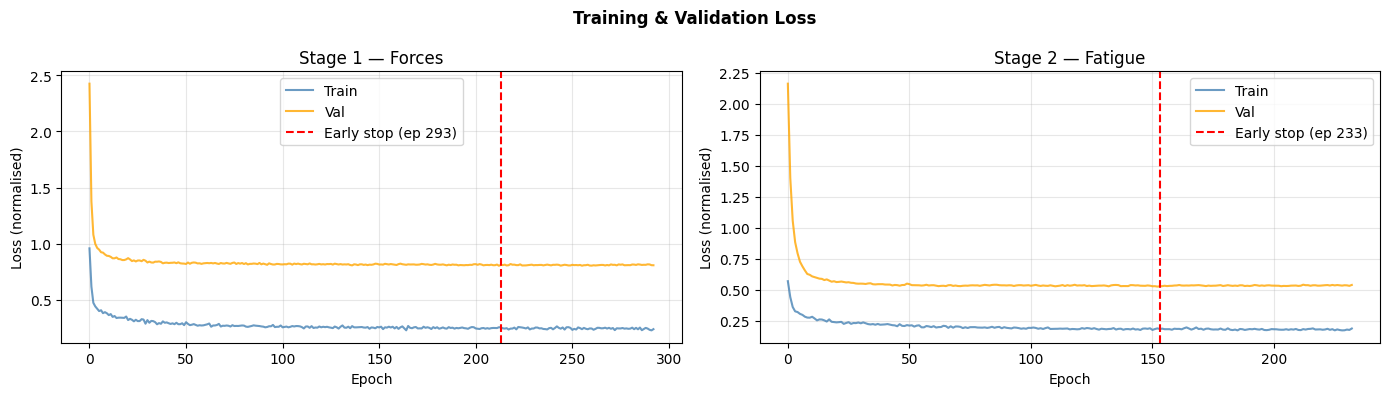

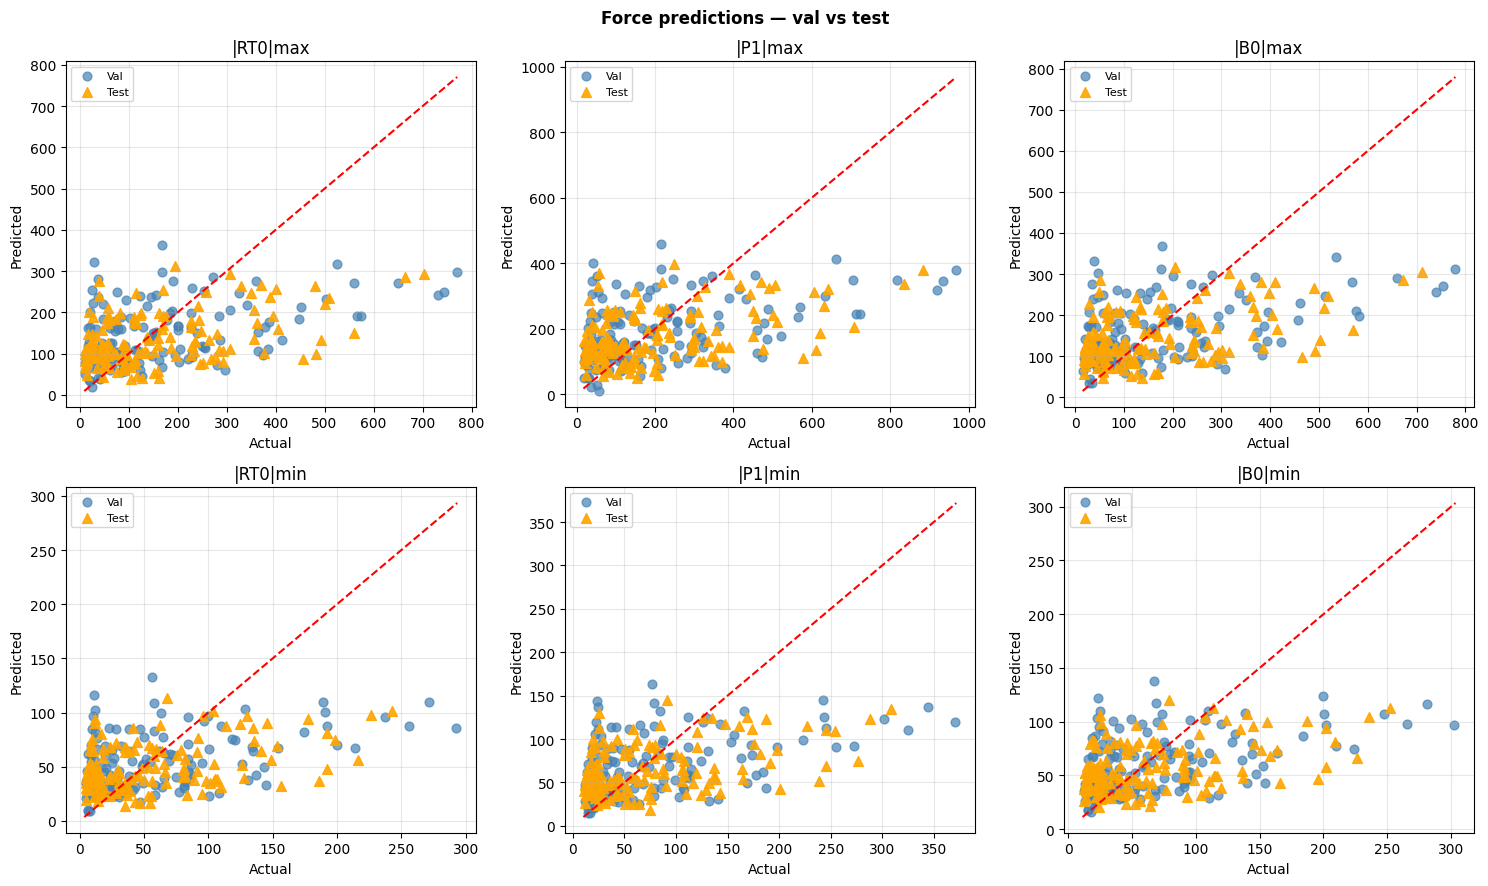

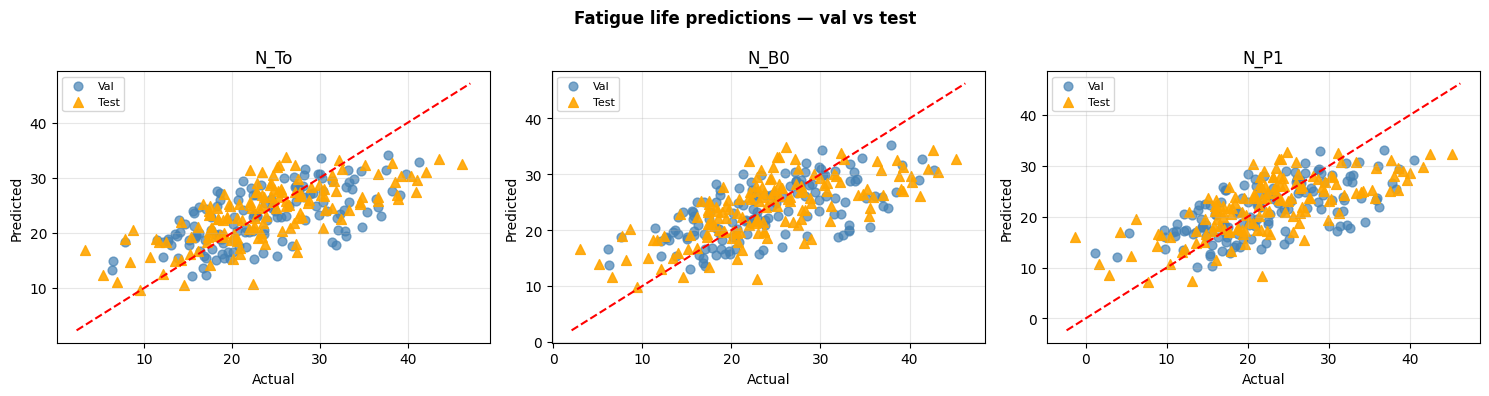

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Training & Validation Loss', fontweight='bold')
for ax, train_h, val_h, stopped, title in [
    (axes[0], force_train_hist,   force_val_hist,   stopped_force,   'Stage 1 — Forces'),
    (axes[1], fatigue_train_hist, fatigue_val_hist, stopped_fatigue, 'Stage 2 — Fatigue'),
]:
    ax.plot(train_h, label='Train', color='steelblue', alpha=0.8)
    ax.plot(val_h,   label='Val',   color='orange',    alpha=0.8)
    ax.axvline(stopped - patience, color='red', linestyle='--', label=f'Early stop (ep {stopped})')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (normalised)')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

n_f = len(force_cols)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Force predictions — val vs test', fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(force_cols):
    ax = axes[i]
    ax.scatter(tf_val_w[:, i], pf_val_w[:, i], alpha=0.7, color='steelblue', s=40, label='Val')
    ax.scatter(tf_te_w[:,  i], pf_te_w[:,  i], alpha=0.9, color='orange',    s=50, label='Test', marker='^')
    lo = min(tf_val_w[:, i].min(), tf_te_w[:, i].min()) - 1
    hi = max(tf_val_w[:, i].max(), tf_te_w[:, i].max()) + 1
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_title(col); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('force_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

n_a = len(fatigue_cols)
fig, axes = plt.subplots(1, n_a, figsize=(5 * n_a, 4))
fig.suptitle('Fatigue life predictions — val vs test', fontweight='bold')
for i, col in enumerate(fatigue_cols):
    ax = axes[i]
    ax.scatter(ta_val_w[:, i], pa_val_w[:, i], alpha=0.7, color='steelblue', s=40, label='Val')
    ax.scatter(ta_te_w[:,  i], pa_te_w[:,  i], alpha=0.9, color='orange',    s=50, label='Test', marker='^')
    lo = min(ta_val_w[:, i].min(), ta_te_w[:, i].min()) - 1
    hi = max(ta_val_w[:, i].max(), ta_te_w[:, i].max()) + 1
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_title(col); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fatigue_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 13 — Experiment Logger

In [13]:
log_file   = 'experiment_log.csv'
run_number = 0
if os.path.isfile(log_file):
    df_log     = pd.read_csv(log_file)
    run_number = len(df_log)

dropout_val = 0.0
for module in force_model.modules():
    if isinstance(module, nn.Dropout):
        dropout_val = module.p; break

norm_type = 'None'
for module in force_model.modules():
    if isinstance(module, nn.LayerNorm):
        norm_type = 'LayerNorm'; break
    elif isinstance(module, nn.BatchNorm1d):
        norm_type = 'BatchNorm1d'; break

has_skip = hasattr(force_model, 'skip')

for m in force_model.hidden1:
    if isinstance(m, nn.Linear): w1 = m.out_features; break
for m in force_model.hidden2:
    if isinstance(m, nn.Linear): w2 = m.out_features; break
force_widths = f'{w1} → {w2}'

for m in fatigue_model.hidden1:
    if isinstance(m, nn.Linear): fw1 = m.out_features; break
for m in fatigue_model.hidden2:
    if isinstance(m, nn.Linear): fw2 = m.out_features; break
fatigue_widths = f'{fw1} → {fw2}'
if has_skip:
    force_widths   += ' + skip'
    fatigue_widths += ' + skip'

n_params_force   = sum(p.numel() for p in force_model.parameters())
n_params_fatigue = sum(p.numel() for p in fatigue_model.parameters())

run_config = {
    'run_number'       : run_number + 1,
    'timestamp'        : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'dataset'          : 'MLPartB3',
    'split_method'     : 'stratified_FOS',
    'loss_force'       : 'HuberLoss(delta=1.0)',
    'loss_fatigue'     : 'FatigueLoss(delta=0.5,overpredict=1.5)',
    'hidden_force'     : force_widths,
    'hidden_fatigue'   : fatigue_widths,
    'norm_type'        : norm_type,
    'skip_connection'  : has_skip,
    'n_params_force'   : n_params_force,
    'n_params_fatigue' : n_params_fatigue,
    'optimizer'        : type(optimizer_force).__name__,
    'lr'               : optimizer_force.param_groups[0]['lr'],
    'weight_decay'     : optimizer_force.param_groups[0].get('weight_decay', 0),
    'dropout'          : dropout_val,
    'lambda_pinn'      : Lambda,
    'epochs_max'       : epochs,
    'stopped_force'    : stopped_force,
    'stopped_fatigue'  : stopped_fatigue,
    'best_force_val'   : round(best_force_val, 6),
    'best_fatigue_val' : round(best_fatigue_val, 6),
    'patience'         : patience,
    'batch_size'       : batch_size,
    'alpha_mixup'      : alpha,
    'n_features'       : len(feature_cols),
    'n_dim_features'   : len(dimensionless_cols),
    'n_force_outputs'  : n_force,
    'n_fatigue_outputs': n_fatigue,
    'seed'             : seed,
    'n_total'          : len(x),
    'n_train'          : len(train_idx),
    'n_val'            : len(val_idx),
    'n_test'           : len(test_idx),
    'notes'            : '',
}

run_metrics = {}
for col in force_cols:
    for split, res in [('val', val_force_res), ('test', test_force_res)]:
        run_metrics[f'{col}_{split}_mae']  = round(res[col]['mae'],  4)
        run_metrics[f'{col}_{split}_rmse'] = round(res[col]['rmse'], 4)
        run_metrics[f'{col}_{split}_mse']  = round(res[col]['rmse']**2, 4)
        run_metrics[f'{col}_{split}_r2']   = round(res[col]['r2'],   4)
for col in fatigue_cols:
    for split, res in [('val', val_fat_res), ('test', test_fat_res)]:
        run_metrics[f'{col}_{split}_mae']  = round(res[col]['mae'],  4)
        run_metrics[f'{col}_{split}_rmse'] = round(res[col]['rmse'], 4)
        run_metrics[f'{col}_{split}_mse']  = round(res[col]['rmse']**2, 4)
        run_metrics[f'{col}_{split}_r2']   = round(res[col]['r2'],   4)
for split in ['val', 'test']:
    force_r2s  = [run_metrics[f'{c}_{split}_r2']  for c in force_cols]
    force_maes = [run_metrics[f'{c}_{split}_mae'] for c in force_cols]
    fat_r2s    = [run_metrics[f'{c}_{split}_r2']  for c in fatigue_cols]
    fat_maes   = [run_metrics[f'{c}_{split}_mae'] for c in fatigue_cols]
    run_metrics[f'force_mean_{split}_r2']    = round(np.mean(force_r2s),  4)
    run_metrics[f'force_mean_{split}_mae']   = round(np.mean(force_maes), 4)
    run_metrics[f'fatigue_mean_{split}_r2']  = round(np.mean(fat_r2s),    4)
    run_metrics[f'fatigue_mean_{split}_mae'] = round(np.mean(fat_maes),   4)

row = {**run_config, **run_metrics}
if os.path.isfile(log_file):
    existing = pd.read_csv(log_file)
    new_row  = pd.DataFrame([row])
    combined = pd.concat([existing, new_row], ignore_index=True)
else:
    combined = pd.DataFrame([row])
combined.to_csv(log_file, index=False)

print('=' * 70)
print(f'  Run {run_config["run_number"]} logged → {log_file}')
print('=' * 70)
print(f'  Dataset       : {run_config["dataset"]}')
print(f'  Split         : {run_config["split_method"]}')
print(f'  Loss          : force={run_config["loss_force"]}  fatigue={run_config["loss_fatigue"]}')
print(f'  Force arch    : {force_widths}  ({n_params_force:,} params)')
print(f'  Fatigue arch  : {fatigue_widths}  ({n_params_fatigue:,} params)')
print(f'  Norm          : {norm_type}   Skip: {has_skip}')
print(f'  Optimizer     : {run_config["optimizer"]}  lr={run_config["lr"]}  wd={run_config["weight_decay"]}')
print(f'  Dropout       : {dropout_val}   Mixup α: {alpha}')
print(f'  Features      : {len(feature_cols)} ({len(dimensionless_cols)} dimensionless)')
print(f'  Stopped       : force={stopped_force}  fatigue={stopped_fatigue}  / {epochs}')
print(f'  Best val loss : force={best_force_val:.6f}  fatigue={best_fatigue_val:.6f}')
print('=' * 70)


  Run 1 logged → experiment_log.csv
  Dataset       : MLPartB3
  Split         : stratified_FOS
  Loss          : force=HuberLoss(delta=1.0)  fatigue=FatigueLoss(delta=0.5,overpredict=1.5)
  Force arch    : 128 → 256 + skip  (40,710 params)
  Fatigue arch  : 64 → 128 + skip  (12,931 params)
  Norm          : LayerNorm   Skip: True
  Optimizer     : AdamW  lr=0.0001  wd=0.005
  Dropout       : 0.15   Mixup α: 0.5
  Features      : 13 (7 dimensionless)
  Stopped       : force=293  fatigue=233  / 800
  Best val loss : force=0.803560  fatigue=0.523744


## Cell 14 — SHAP Analysis